# Simple Linear Regression 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/nabinbisht/Documents/Dataset/babies.csv", index_col= "case" )

In [4]:
df

,bwt,gestation,parity,age,height,weight,smoke
case,,,,,,,
1,120,284.0,0,27.0,62.0,100.0,0.0
2,113,282.0,0,33.0,64.0,135.0,0.0
3,128,279.0,0,28.0,64.0,115.0,1.0
4,123,NaN,0,36.0,69.0,190.0,0.0
5,108,282.0,0,23.0,67.0,125.0,1.0
...,...,...,...,...,...,...,...
1232,113,275.0,1,27.0,60.0,100.0,0.0
1233,128,265.0,0,24.0,67.0,120.0,0.0
1234,130,291.0,0,30.0,65.0,150.0,1.0


In [81]:
df.describe()

,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1236 entries, 1 to 1236
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   bwt        1236 non-null   int64  
 1   gestation  1223 non-null   float64
 2   parity     1236 non-null   int64  
 3   age        1234 non-null   float64
 4   height     1214 non-null   float64
 5   weight     1200 non-null   float64
 6   smoke      1226 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 77.2 KB


In [83]:
df.isnull().sum()

bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [84]:
df.dropna(inplace=True)

<Axes: xlabel='age', ylabel='Count'>

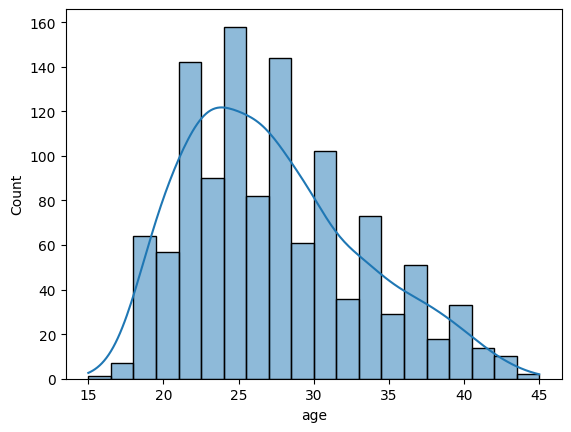

In [85]:
sns.histplot(data= df["age"] , kde=True)

<Axes: xlabel='height', ylabel='weight'>

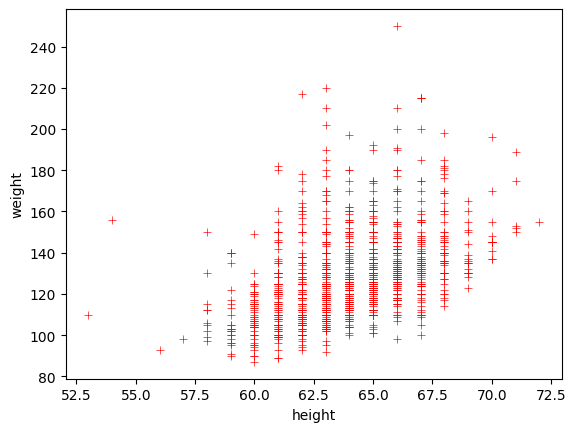

In [111]:
sns.scatterplot(data = df, x= 'height', y= 'weight', marker= '+', color = "red")

In [109]:
correlation = df.corr()
correlation

,bwt,gestation,parity,age,height,weight,smoke
bwt,1.000000,0.407543,-0.043908,0.026983,0.203704,0.155923,-0.246800
gestation,0.407543,1.000000,0.080916,-0.053425,0.070470,0.023655,-0.060267
parity,-0.043908,0.080916,1.000000,-0.351041,0.043543,-0.096362,-0.009599
age,0.026983,-0.053425,-0.351041,1.000000,-0.006453,0.147322,-0.067772
height,0.203704,0.070470,0.043543,-0.006453,1.000000,0.435287,0.017507
weight,0.155923,0.023655,-0.096362,0.147322,0.435287,1.000000,-0.060281
smoke,-0.246800,-0.060267,-0.009599,-0.067772,0.017507,-0.060281,1.000000


<Axes: >

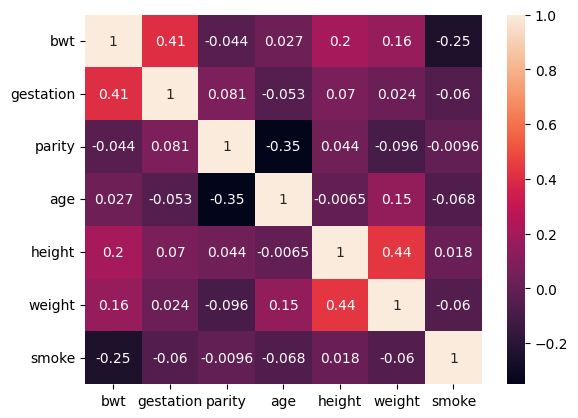

In [110]:
sns.heatmap(data=correlation, annot=True)

# Simple Linear Regression

In [112]:
X = df[['height']] # independent
y = df['weight'] # Dependent, or predicted, or targeted variables

In [113]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=42)


In [114]:
print(df.shape)
print(x_train.shape)
print(x_test.shape)

(1174, 7)
(821, 1)
(353, 1)


In [115]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [116]:
coeficient = model.coef_
intercept = model.intercept_

print(f"The value of coeficient is {coeficient} and intercept is {intercept}")

The value of coeficient is [3.57284626] and intercept is -100.35996730828637


## Original dataset that we are goinging to predict (Independent variable)

In [117]:
print(x_test)

      height
case        
442     62.0
463     66.0
722     64.0
227     66.0
862     62.0
...      ...
803     62.0
611     61.0
577     65.0
1214    69.0
494     65.0

[353 rows x 1 columns]


# 2. Compare below both
## Comapre Both Predicted with Original


## Predicted values from X_test

In [118]:
model.predict(x_test)

array([121.15650077, 135.4478858 , 128.30219329, 135.4478858 ,
       121.15650077, 135.4478858 , 117.58365451, 124.72934703,
       139.02073206, 110.43796199, 121.15650077, 131.87503954,
       117.58365451, 139.02073206, 131.87503954, 128.30219329,
       110.43796199, 135.4478858 , 128.30219329, 128.30219329,
       117.58365451, 121.15650077, 142.59357832, 131.87503954,
       131.87503954, 139.02073206, 142.59357832, 131.87503954,
       128.30219329, 139.02073206, 128.30219329, 128.30219329,
       149.73927084, 124.72934703, 146.16642458, 121.15650077,
       117.58365451, 117.58365451, 131.87503954, 139.02073206,
       153.3121171 , 124.72934703, 131.87503954, 131.87503954,
       131.87503954, 121.15650077, 124.72934703, 128.30219329,
       131.87503954, 139.02073206, 121.15650077, 128.30219329,
       117.58365451, 135.4478858 , 121.15650077, 124.72934703,
       135.4478858 , 114.01080825, 139.02073206, 128.30219329,
       139.02073206, 128.30219329, 121.15650077, 114.01

## Original Dataset (Y_test)

In [119]:
print(y_test)

case
442     108.0
463     149.0
722     160.0
227     128.0
862     112.0
        ...  
803     127.0
611     100.0
577     132.0
1214    151.0
494     118.0
Name: weight, Length: 353, dtype: float64


# The Value of R-Square 

In [120]:
r_square = model.score(x_test,y_test)
print(f"The Value of R_Sqaure is {r_square}")

The Value of R_Sqaure is 0.21384501145194867


# END

## 2. Multiple Linear regression (Baby Birth Wight Prediction)

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_csv("/Users/nabinbisht/Documents/Dataset/babies.csv", index_col= "case" )

In [68]:
#df.dropna(inplace=True)

In [69]:
X = df[['gestation', 'parity', 'age', 'height', 'weight', 'smoke']]
y = df['bwt']

In [70]:
df.dropna(inplace=True)

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

model = LinearRegression()

model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

model.predict(x_test)

array([128.18684191, 100.56781908,  99.35078376, 130.50387995,
       125.70692749, 123.73103548, 111.86775325, 117.24358316,
       125.46123121, 104.63184882, 154.17965323, 118.13664349,
       117.42317736, 134.56463755, 119.21999993, 127.83700402,
       123.51528819, 123.20000599, 125.46812345, 117.99919838,
        94.62101326, 111.24799559, 126.31805882, 123.84999941,
       122.75339958, 107.73545492, 115.47601107, 101.63519508,
       112.25749682, 114.32880194, 128.00236182, 133.45951418,
       113.43323895, 121.87629879, 112.70653124, 126.25370121,
       114.13687453, 142.99034895, 116.49934786, 115.03154356,
       111.79753035, 121.39818087, 111.86035884, 129.16160511,
       120.85792838, 120.75541134, 110.87567959, 121.16111946,
       117.69820282, 119.0412901 , 115.23660035, 132.83579308,
       119.83179266, 120.07287765, 107.12177794, 122.25857519,
       127.15920106, 114.01098178,  99.21366848, 120.87020816,
       103.01459794, 115.1695352 , 125.39425694, 124.22

In [79]:
print("\n--- Linear Regression ---")

predictions = model.predict(x_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


--- Linear Regression ---
Mean Squared Error: 262.30
R-squared: 0.28


## Scatter plot of predictions vs. actual values¶

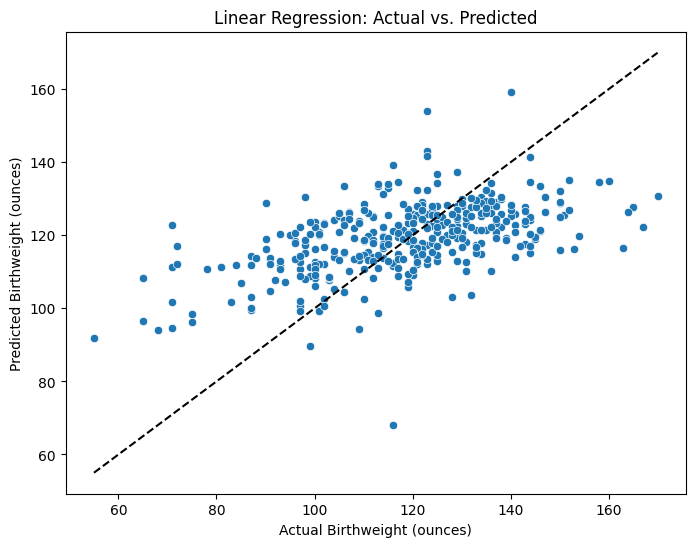

In [81]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel("Actual Birthweight (ounces)")
plt.ylabel("Predicted Birthweight (ounces)")
plt.title("Linear Regression: Actual vs. Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--') # Diagonal line for perfect predictions
plt.show()

# 3.Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train, y_train)

rf_predictions = rf_model.predict(x_test)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"R-squared: {rf_r2:.2f}")


--- Random Forest Regressor ---
Mean Squared Error: 283.31
R-squared: 0.22
